In [20]:
import numpy as np
import scanpy as sc
import seaborn as sns
import anndata as ad
import pandas as pd
from sklearn.decomposition import NMF
import sys
sys.path.append('../simulation/')
sys.path.append('../../sc_simulator/simulator/')
sys.path.append('../../Simulator/')
# from simulator import dropletFormation, absoluteLS, generate_alpha_arr, cell_probV,simulate_Droplets,LS_recession,sampling
from hiererchical_simulator import get_data_and_visualize
from high_dim_simulator import dimension_rising, generate_markov_kernel
# data_df, adata = get_data_and_visualize(tree_id=17)
# sc.pp.normalize_total(adata, target_sum=1e4)

Parsing xml tree file...
Generating alpha matrix...


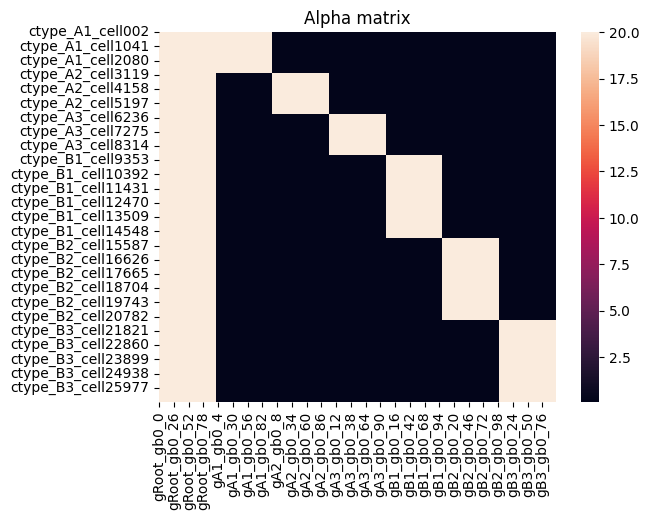

Sampling p's from Dirichlet distribution...
Sampling cell total UMIs from logNormal distribution...
A1 10 1.0
A2 8 1.0
A3 9 1.0
B1 10 1.0
B2 8 1.0
B3 9 1.0
Sampling cells from multinomial distribution...


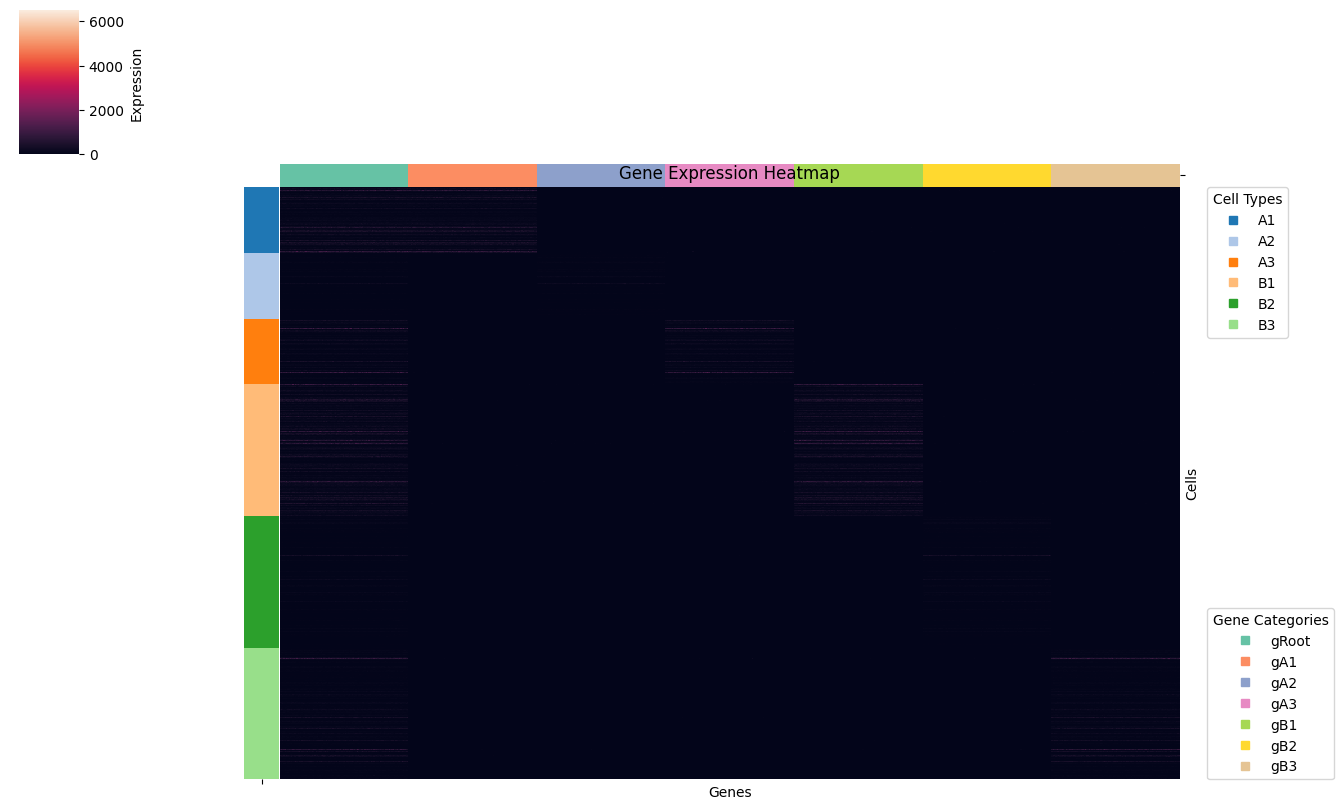

Saving anndata to: ../sim_data/adata/adata_2.h5ad


In [25]:
data_df, adata = get_data_and_visualize(tree_id=2)

<Axes: >

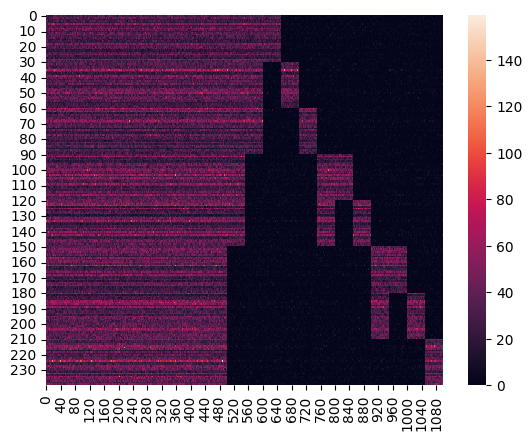

In [23]:
sns.heatmap(adata.X)

In [15]:
X = adata.X.copy()
X = X/X.sum(axis=1, keepdims=True)
X[1200:, 3:5] = np.random.normal(loc=0.02, scale=0.00001, size=X[1200:, 3:5].shape)
X[0:1500, 6:] = np.random.normal(loc=0.02, scale=0.00001, size=X[0:1500, 6:].shape)
# X = X/X.sum(axis=1, keepdims=True)

In [16]:
X[:900,3:5]

array([[0.15820529, 0.04684777],
       [0.19177624, 0.04919768],
       [0.21112331, 0.10336626],
       ...,
       [0.11512487, 0.1239594 ],
       [0.17510404, 0.08222436],
       [0.17786475, 0.1068167 ]], shape=(900, 2))

<Axes: >

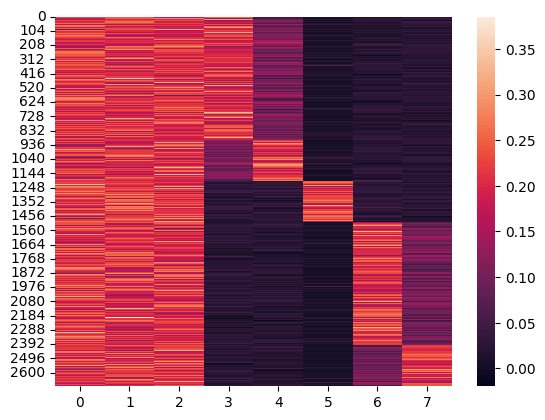

In [4]:
sns.heatmap(X)

In [5]:
adata.X = X.copy()

In [6]:
P, A = dimension_rising(X.T, 200)

<Axes: >

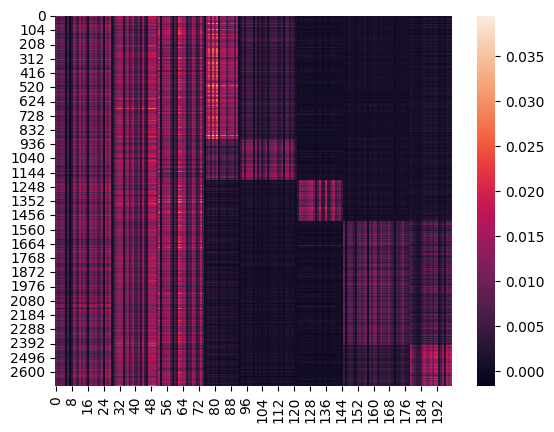

In [7]:
sns.heatmap(P.T)

In [8]:
P = np.clip(P, a_min=0, a_max=1)

In [9]:
libsize1 = np.linspace(4,5.5,5)
libsize2 = np.linspace(5.5,7,5)
libsize3 = np.linspace(4,5.5,5)

In [16]:
lib = []
for idx in range(len(libsize1)):
    x1 = np.random.lognormal(mean=libsize1[idx], sigma=0.2, size=1200)
    x2 = np.random.lognormal(mean=libsize2[idx], sigma=0.2, size=300)
    x3 = np.random.lognormal(mean=libsize3[idx], sigma=0.2, size=1200)
    x= np.concat([x1,x2,x3])
    lib.append(x)

In [11]:
def gen_multinomial_matrix(PT, x, n_min=1, n_round="round", rng=None):

    PT = np.asarray(PT, dtype=float)
    x = np.asarray(x, dtype=float)
    assert PT.ndim == 2
    N, G = PT.shape
    assert x.shape == (N,)


    PT = np.clip(PT, 0.0, None)
    row_sum = PT.sum(axis=1, keepdims=True)
    PT = PT / (row_sum + 1e-12)

    if n_round == "round":
        n = np.rint(x).astype(int)
    elif n_round == "floor":
        n = np.floor(x).astype(int)
    elif n_round == "ceil":
        n = np.ceil(x).astype(int)
    else:
        raise ValueError("n_round must be one of: 'round', 'floor', 'ceil'")
    n = np.maximum(n, n_min)

    rng = np.random.default_rng() if rng is None else rng
    X = np.empty((N, G), dtype=int)
    for i in range(N):
        X[i] = rng.multinomial(n[i], PT[i])

    return X, n


In [12]:
def NMF_decom(X, k=10):
    model = NMF(
        n_components=k,
        init="nndsvda",      # 更稳的初始化
        solver="cd",         # coordinate descent
        beta_loss="frobenius",
        max_iter=2000,
        random_state=0
    )

    W = model.fit_transform(X)   # (n_samples, k)
    H = model.components_        # (k, n_features)

    # 重构与误差
    X_hat = W @ H
    recon_err = np.linalg.norm(X - X_hat, ord="fro")
    return W

In [17]:
X_lis = []
for tot in lib:
    X, _ = gen_multinomial_matrix(P.T, tot)
    X_lis.append(X)

In [93]:
W = NMF_decom(X_lis[0], k=10)

In [15]:
for idx in range(len(X_lis)):
    adata_ = ad.AnnData(X_lis[idx], obs=adata.obs)
    adata_.write("../../../../../nfs/chengwang_data/ICML_data/factor_sim/adata_"+str(idx)+".h5ad")

In [18]:
adata_ = ad.AnnData(X_lis[0], obs=adata.obs)
adata_.write("../../../../../nfs/chengwang_data/ICML_data/factor_sim/adata_0_new.h5ad")

In [19]:
adata.write("../../../../../nfs/chengwang_data/ICML_data/factor_sim/adata_low_new.h5ad")